#### 8. Crie pelo menos outras 2 formas gráficas de exibição dos indicadores acima utilizando matplotlib. Escolha tipos de gráficos diferentes dos dados explorados acima.

1 - gráfico de linhas.  
Para esse gráfico foi preciso combinar os aplicativos com atualizações mais e menos recentes com o método pd.concat().

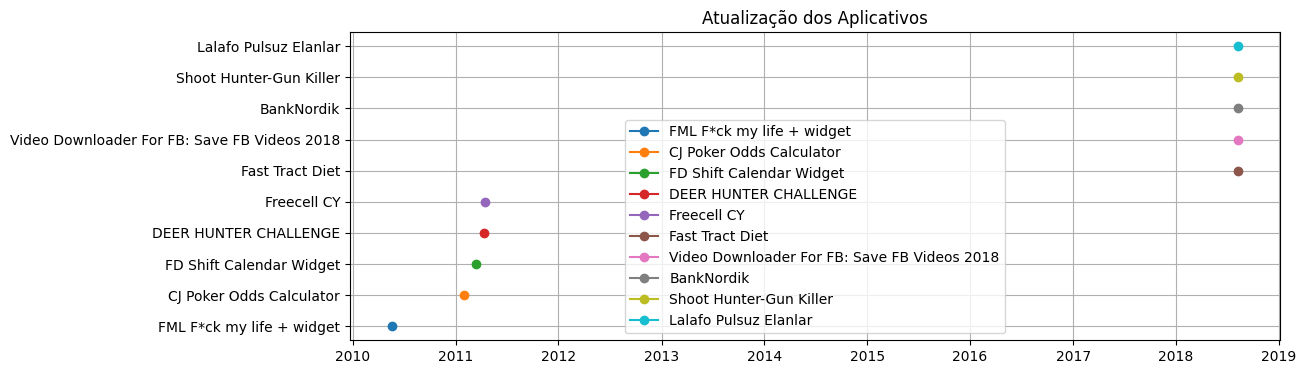

In [1]:
import pandas as pd

import matplotlib.pyplot as mpl

play_store_data = pd.read_csv('/home/andrey/andrey-amaral-compass-uol-1/Sprint03/Desafio/googleplaystore.csv')

play_store_data['Last Updated'] = pd.to_datetime(play_store_data['Last Updated'], errors='coerce')

play_store_data = play_store_data.dropna(subset=['Last Updated'])

play_store_data = play_store_data.drop_duplicates(subset='App', keep='first')

play_store_data = play_store_data.sort_values(by='Last Updated')

apps_atualizados_mais_antigos = play_store_data.head(5)[['App', 'Last Updated']]

apps_atualizados_mais_recentes = play_store_data.tail(5)[['App', 'Last Updated']]

combined_data = pd.concat([apps_atualizados_mais_antigos, apps_atualizados_mais_recentes])

mpl.figure(figsize=(12, 4))

for app in combined_data['App']:
    app_data = combined_data[combined_data['App'] == app]
    mpl.plot(app_data['Last Updated'], app_data['App'], marker='o', label=app)

mpl.title('Atualização dos Aplicativos')

mpl.legend()

mpl.grid(True)

mpl.show()

2 - Histograma.

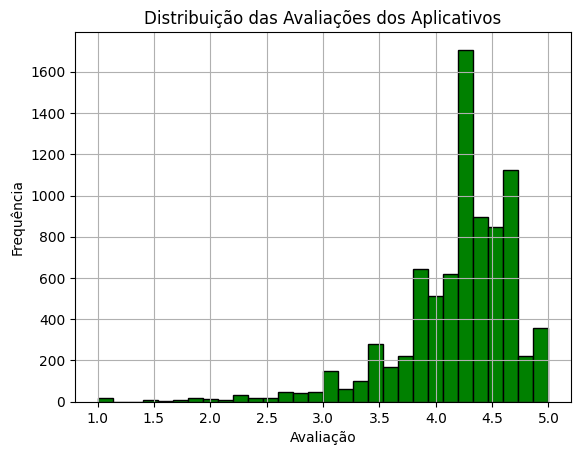

In [2]:
filtered_data = play_store_data[play_store_data['Rating'] <= 5.0]

mpl.hist(filtered_data['Rating'], bins=30, color='green', edgecolor='black')

mpl.xlabel('Avaliação')

mpl.ylabel('Frequência')

mpl.title('Distribuição das Avaliações dos Aplicativos')

mpl.grid(True)

mpl.show()


3 - Como a visualização da distribuição das categorias ficou comprometida no gráfico de pizza da parte 3, plotei na forma de barras laterais aqui.

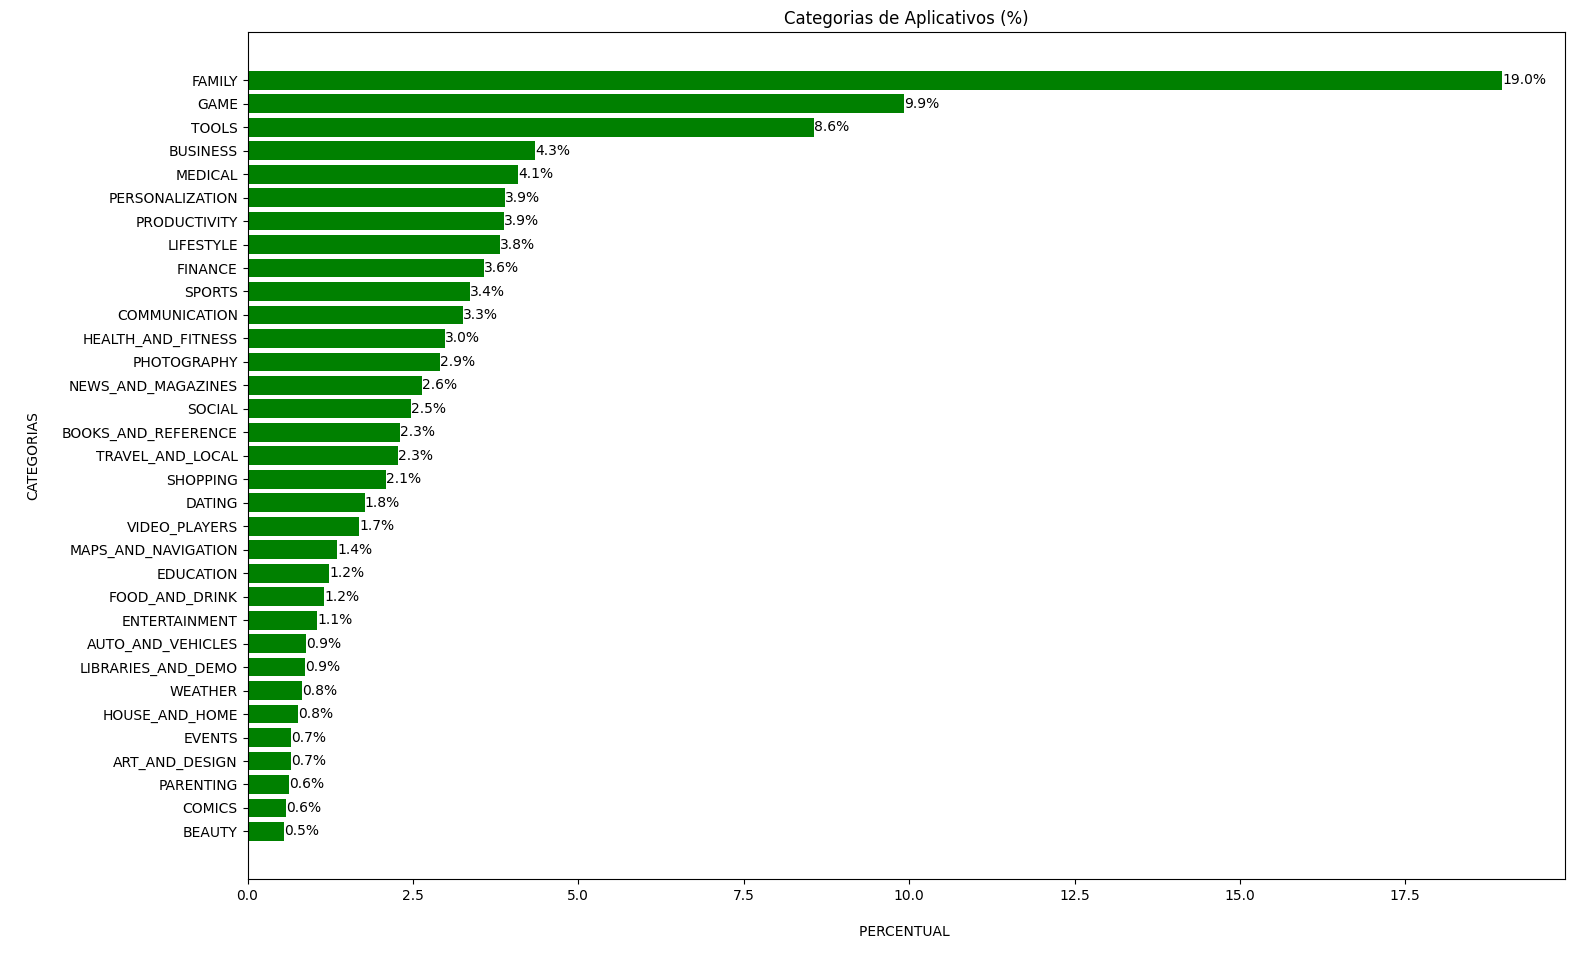

In [3]:
categorias = play_store_data['Category'].value_counts()

total = categorias.sum()

porcentagem_categoria = (categorias / total) * 100

porcentagem_categoria = porcentagem_categoria.sort_values(ascending=True)

mpl.figure(figsize=(17, 11))

mpl.barh(porcentagem_categoria.index, porcentagem_categoria.values, color='Green')

mpl.title('Categorias de Aplicativos (%)')
mpl.xlabel('\nPERCENTUAL \n')
mpl.ylabel('\nCATEGORIAS\n')

for index, value in enumerate(porcentagem_categoria.values):
    mpl.text(value, index, f'{value:.1f}%', va='center')

mpl.show()